In [26]:
# Plant Explorer GFP analysis tutorial
# Updated 2026-07-15

In [27]:
# Set the notebook display method, widget/inline
%matplotlib inline

# Import libraries
from plantcv import plantcv as pcv
from plantcv.parallel import WorkflowInputs
import numpy as np

# Print out the version of PlantCV being used by the Jupyter kernel
pcv.__version__

'4.12.dev701+ge5628e377'

In [28]:
# Input/output options
args = WorkflowInputs(
    images=["img/HDR_GFP-setaria_1_1_default_20260121132136321.INF"],
    names="image1",
    result="results.json",
    outdir="./output",
    writeimg=True,
    debug="plot"
    )

In [29]:
# Set debug to the global parameter 
pcv.params.debug = args.debug
# Change display settings
pcv.params.dpi = 200
pcv.params.text_size = 20
pcv.params.text_thickness = 20

Compiling: CLR
Compiling: SPC


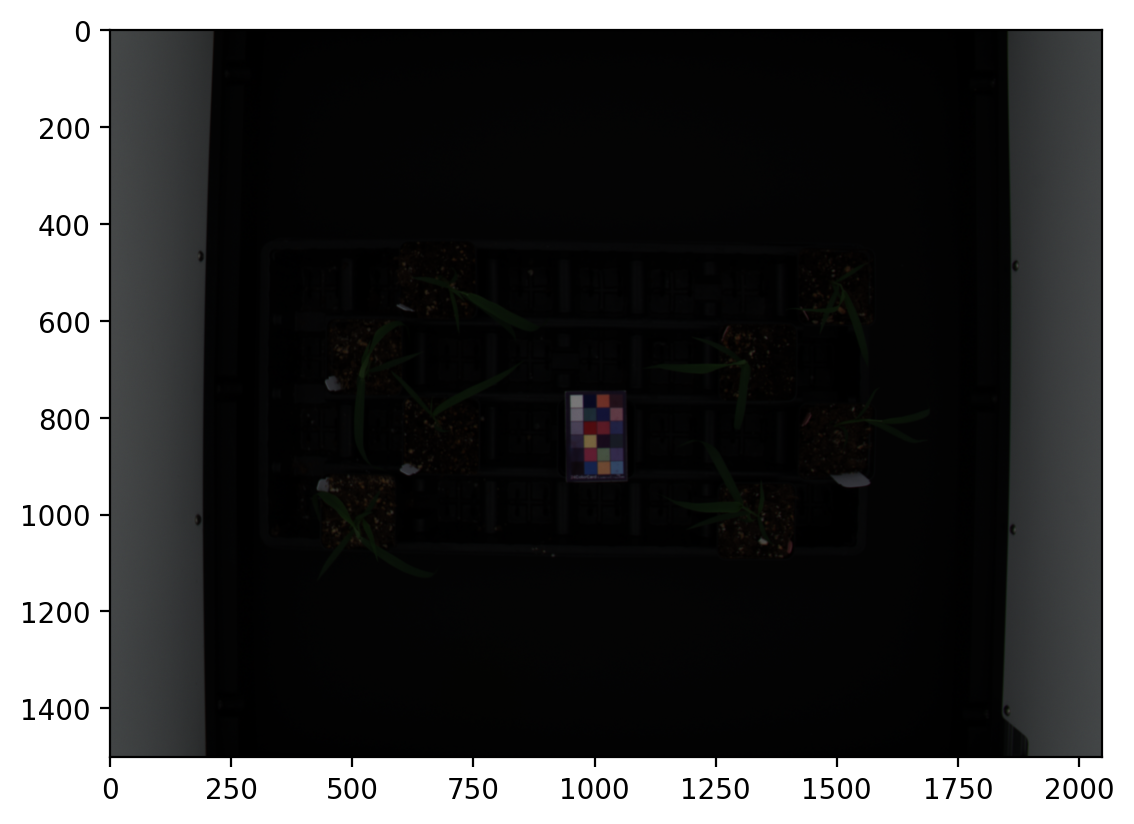

Compiling: GFP
Compiling: RFP


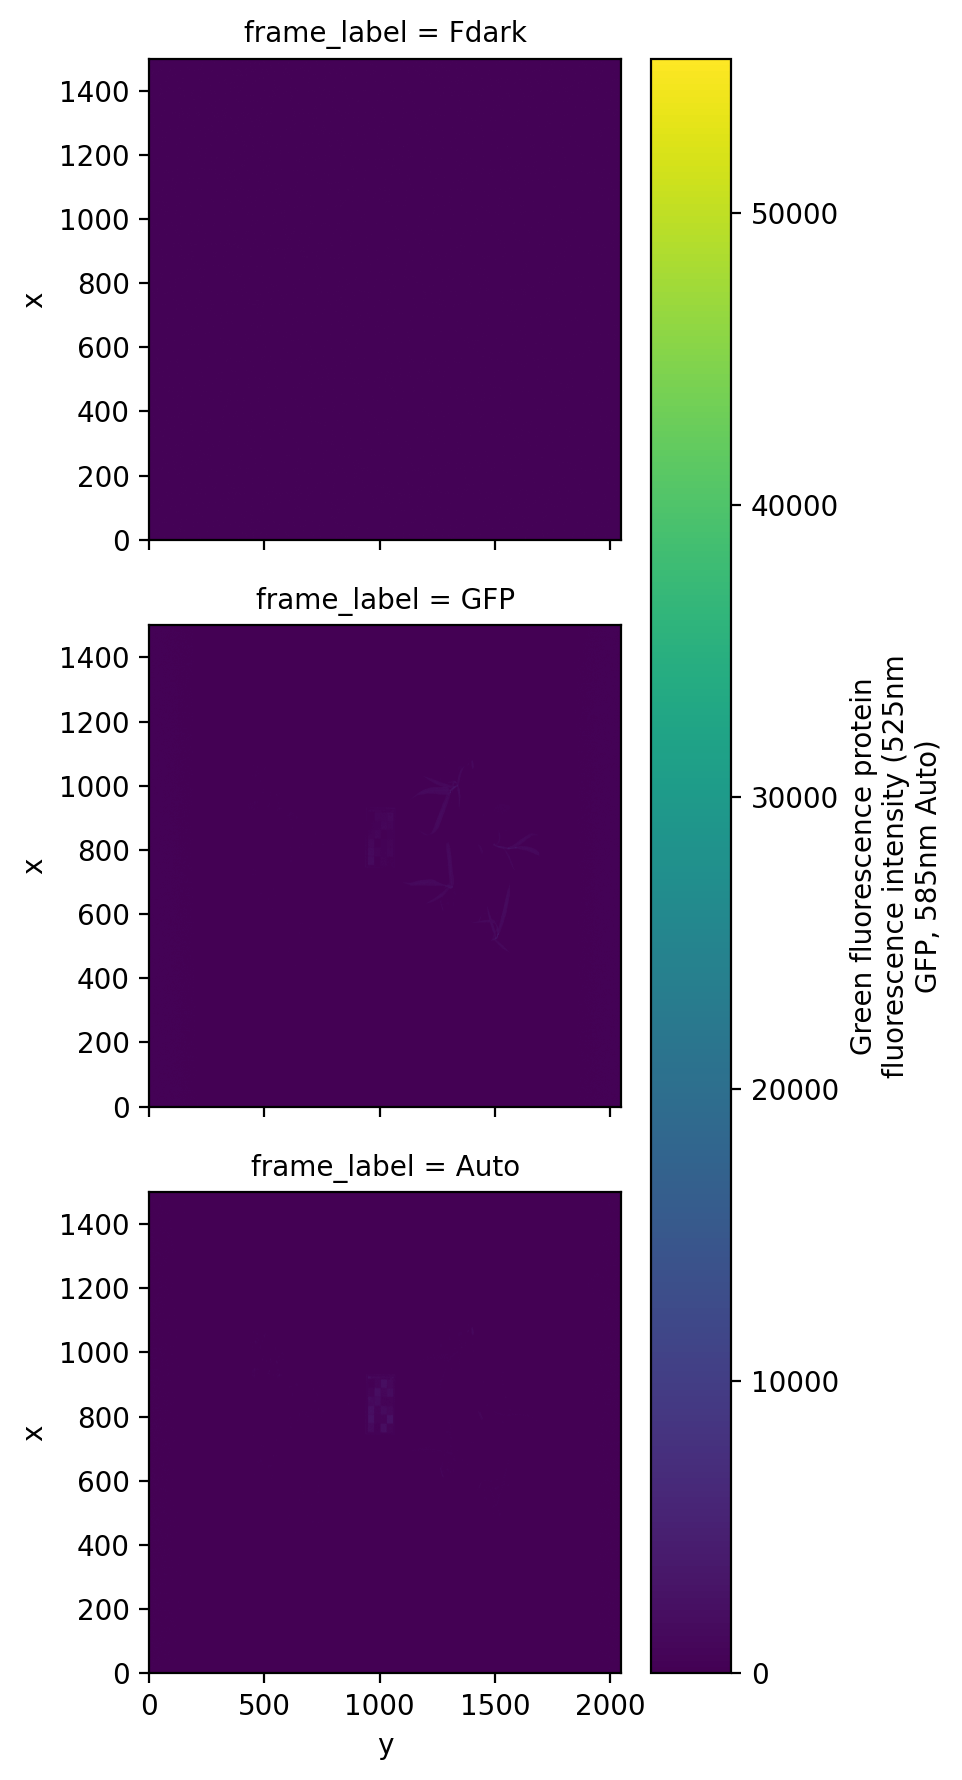

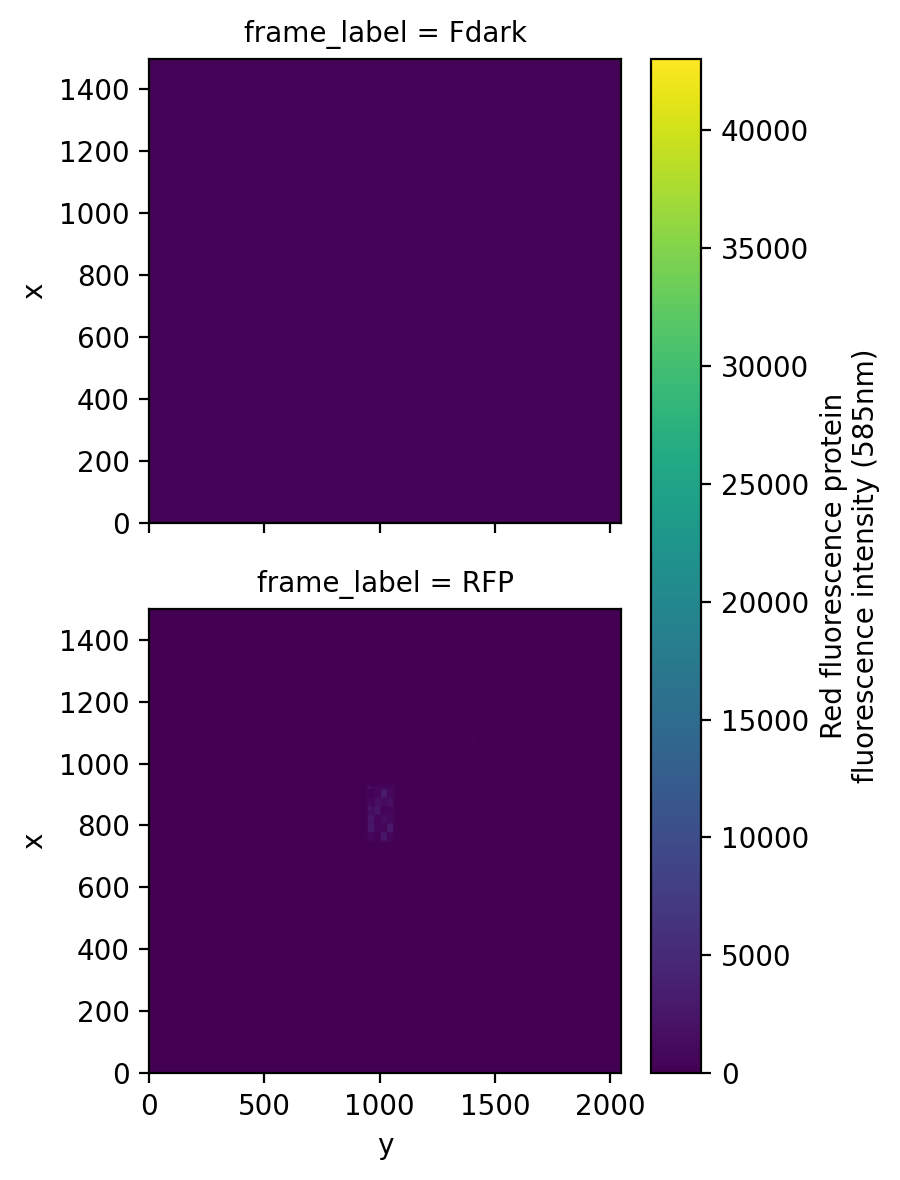

In [30]:
# Read fluorescence image data
# This will visualize all of the frames in all of the data you collected
# Note, the GFP and RFP signal may appear low here

# Inputs:
#   filename - Image file to be read in (should be an .INF file)
ps = pcv.photosynthesis.read_cropreporter(filename=args.image1)

In [31]:
# List available GFP frame labels
print("GFP frames:", ps.gfp.frame_label.values)
print("GFP attrs:", ps.gfp.attrs)

GFP frames: ['Fdark' 'GFP' 'Auto']
GFP attrs: {'long_name': 'Green fluorescence protein fluorescence intensity (525nm GFP, 585nm Auto)', 'dark_comp_on': 1, 'calib_factor': 130.0, 'meas_power': 50.0, 'shutter': 10000.0}


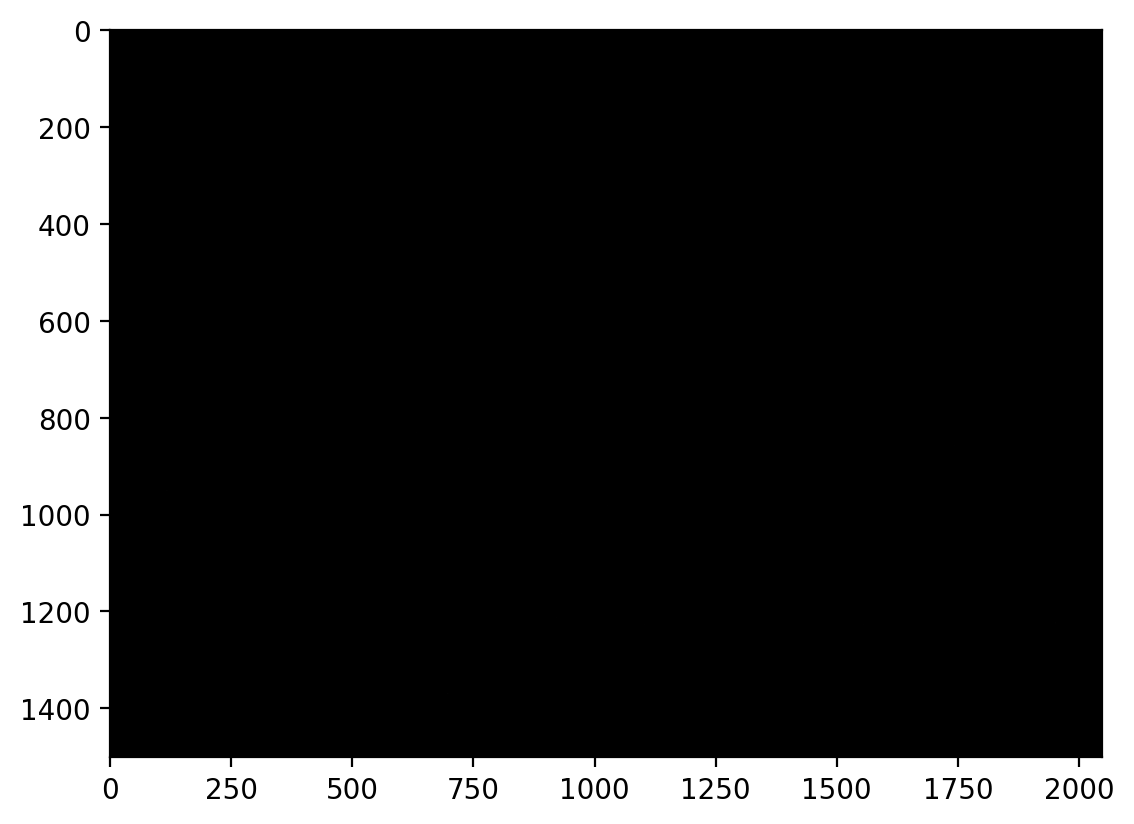

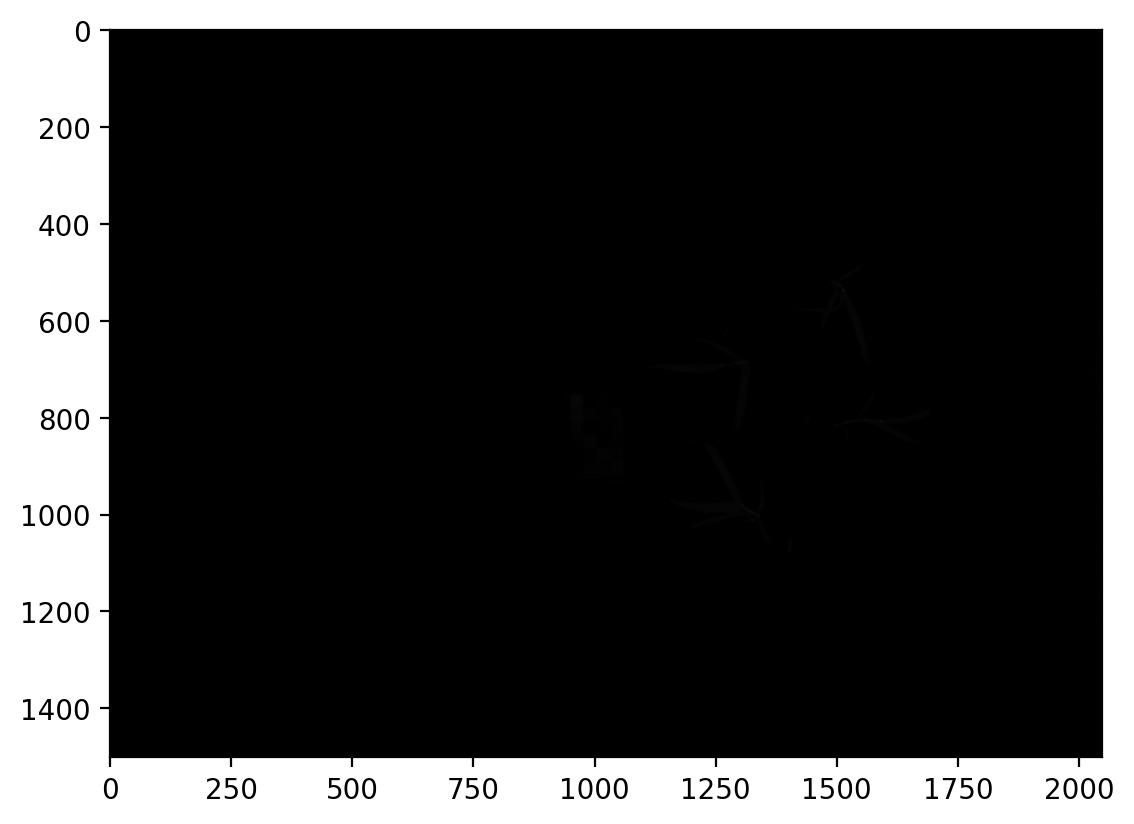

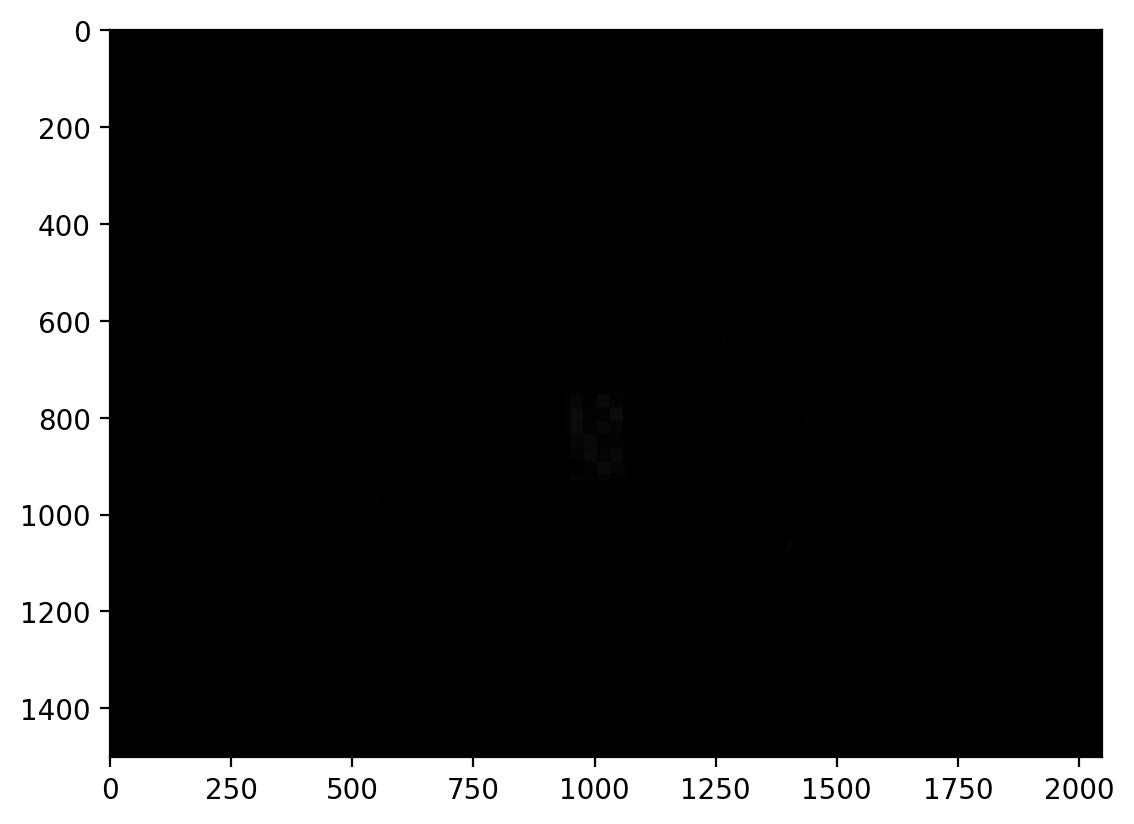

In [32]:
# Pull frames
gfp_fdark_img = ps.gfp.sel(frame_label="Fdark").data
gfp_img = ps.gfp.sel(frame_label="GFP").data
gfp_auto_img = ps.gfp.sel(frame_label="Auto").data

pcv.plot_image(gfp_fdark_img)
pcv.plot_image(gfp_img)
pcv.plot_image(gfp_auto_img)

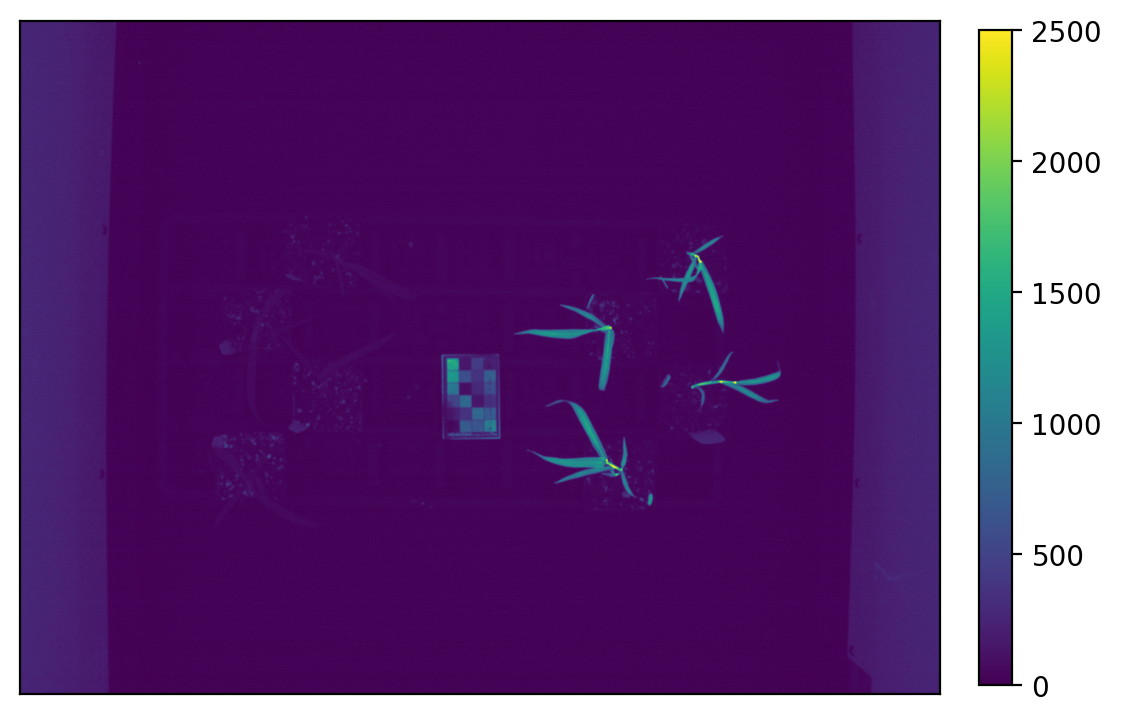

In [33]:
# Pseudocolor an image with 'viridis')
# Change min/max values depending on signal strength
pseudo_img = pcv.visualize.pseudocolor(
    gray_img=gfp_img, 
    mask=None, 
    cmap='viridis',
    min_value=0, 
    max_value=2500
    )

Compiling: CHL


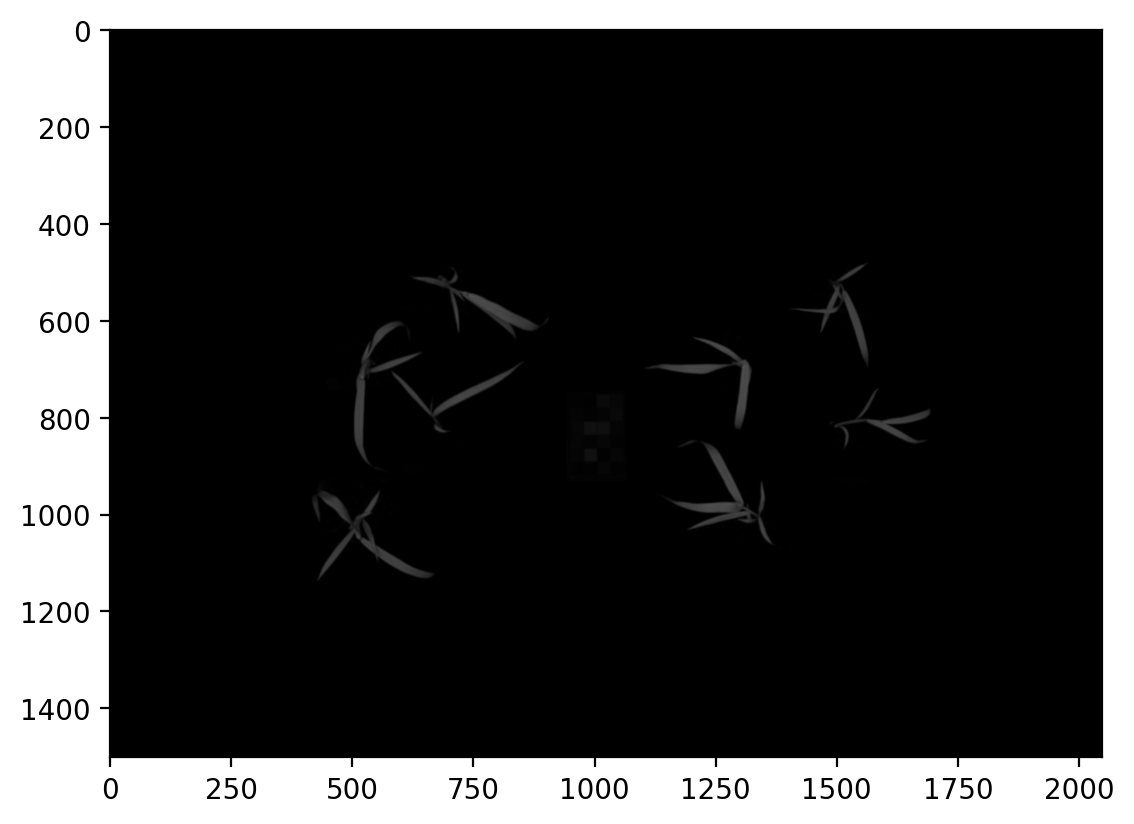

In [34]:
Chl_img = ps.chl.chlorophyll
pcv.plot_image(Chl_img)

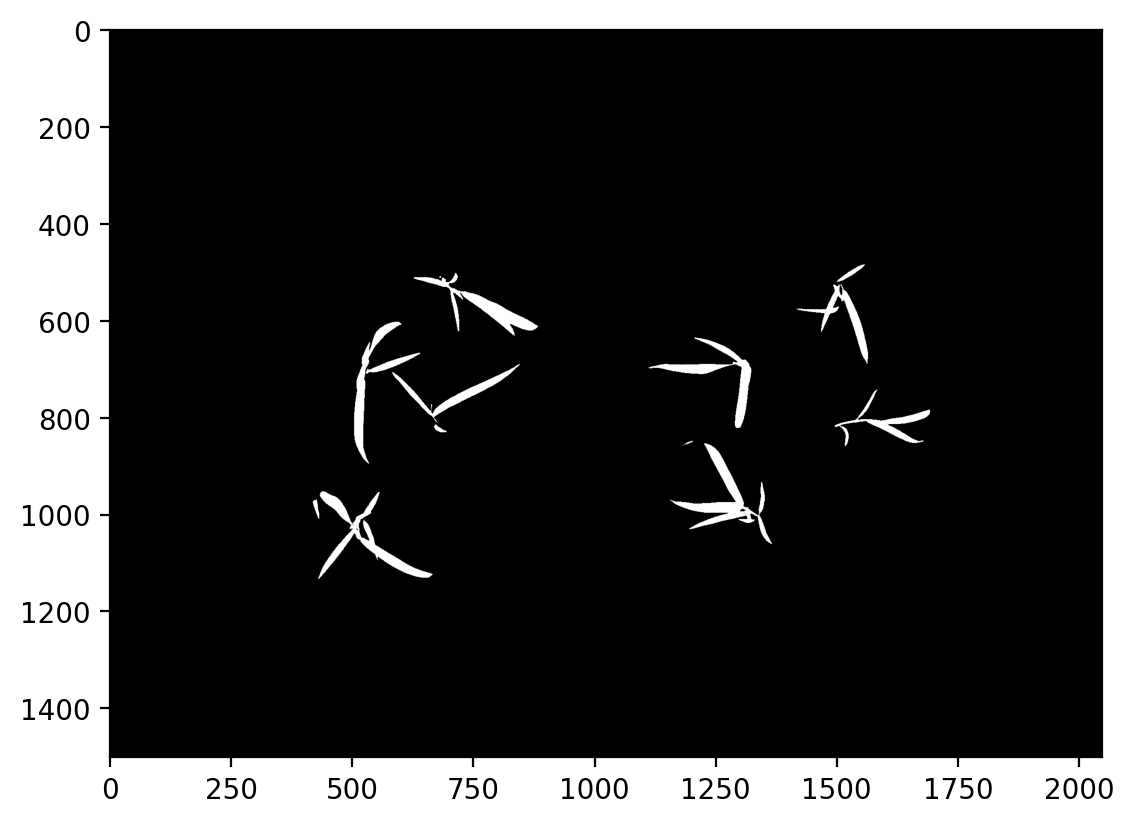

In [35]:
# Threshold the chlorophyll image in order to separate the plant from the background
# For additional thresholding methods (such as binary), see the thresholding tutorial and documentation

# Inputs:
#   gray_img        - Grayscale image data
#   object_type     - 'light' (default) or 'dark'. If the object is lighter than the
#                       background then standard threshold is done. If the object is
#                       darker than the background then inverse thresholding is done.

plant_mask = pcv.threshold.otsu(
    gray_img=Chl_img, 
    object_type="light"
    )

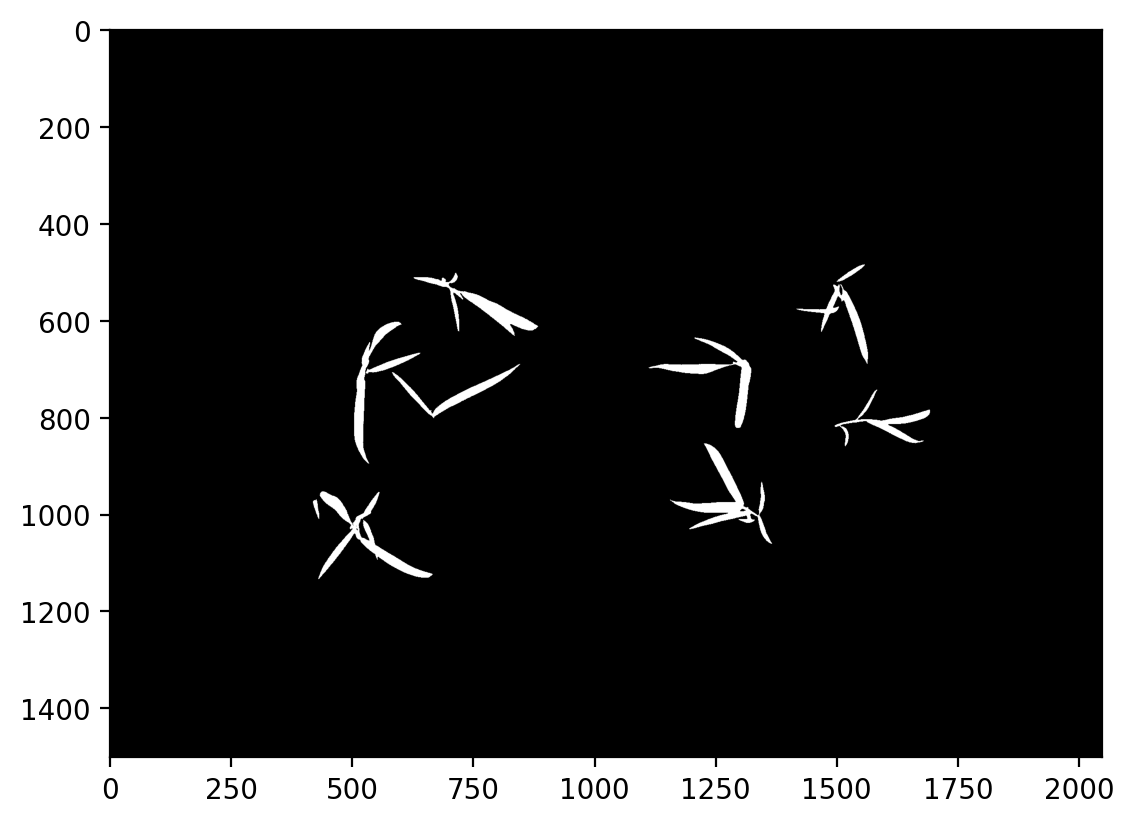

In [36]:
# Fill small objects to remove noise and get a complete plant

# Inputs:
#   bin_img         - Binary image data
#   size            - Minimum object area size in pixels (integer), smaller objects get filled in.

filled_mask = pcv.fill(
    bin_img=plant_mask, 
    size=200
    )

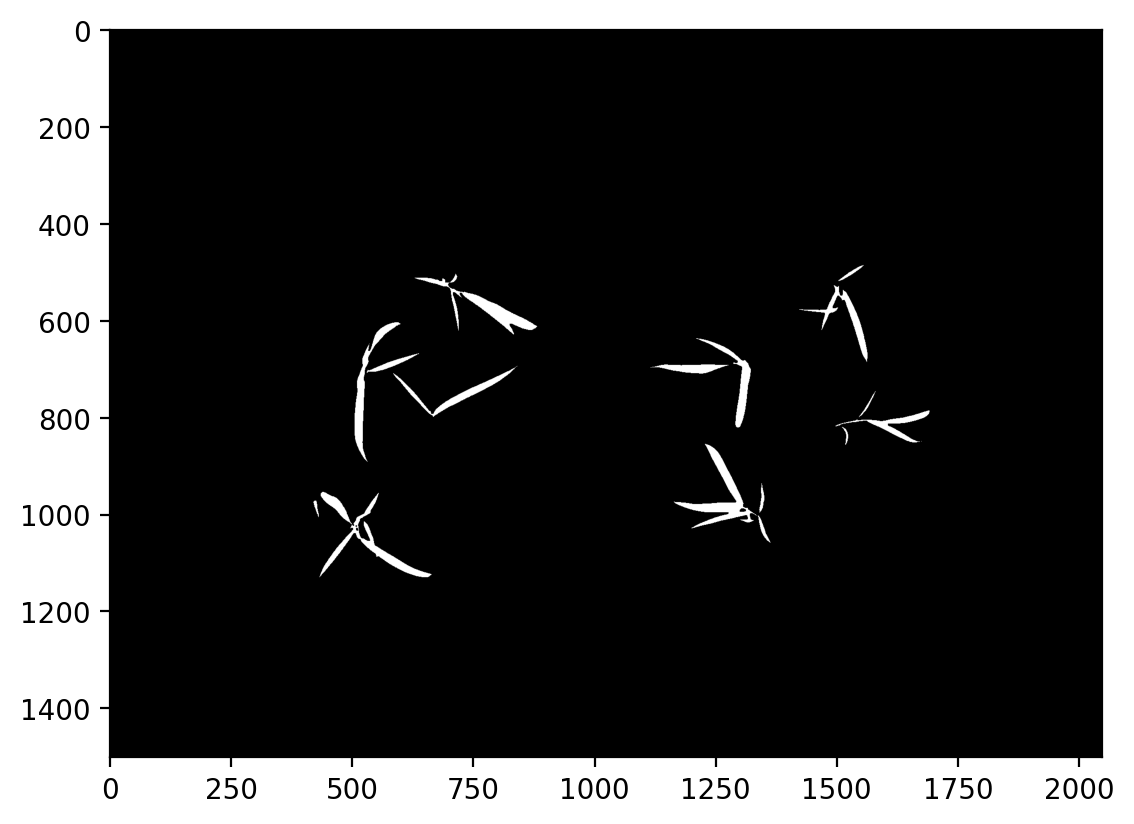

In [37]:
# Erode a small border of pixels from the mask 

# Inputs:
#   gray_img - Grayscale (usually binary) image data 
#   ksize - The size used to build a ksize x ksize 
#            matrix using np.ones. Must be greater than 1 to have an effect 
#   i - An integer for the number of iterations
 
eroded_mask = pcv.erode(
    gray_img=filled_mask, 
    ksize=3, 
    i=1
    )

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..59392].


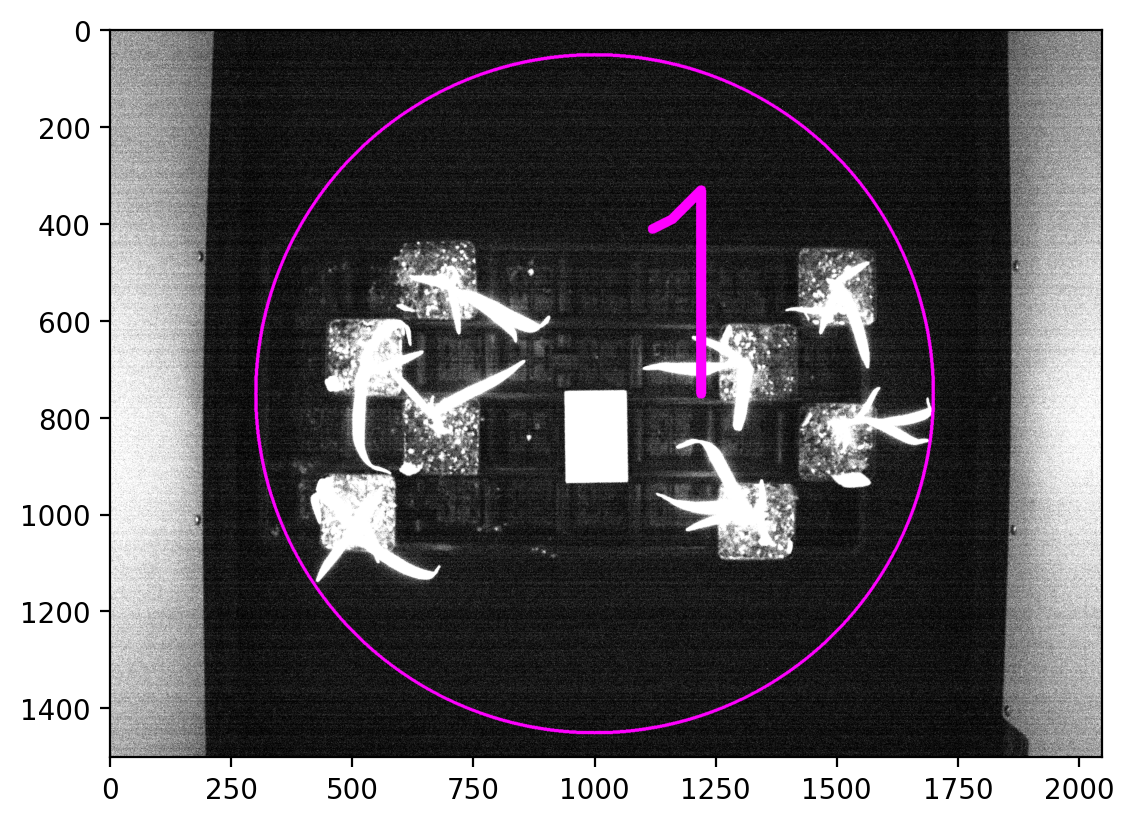

In [38]:
# Define the region of interest (ROI). This should include your plant, but not other things. This is a chance to remove problems in the edges of the image. 

# Inputs: 
#   img - RGB or grayscale image to plot the ROI on 
#   x - The x-coordinate of the center of the circle.
#   y - The y-coordinate of the center of the circle.
#   r - The radius of the circle.

roi = pcv.roi.circle(
    img=Chl_img, 
    x=1000, 
    y=750, 
    r=700
    )

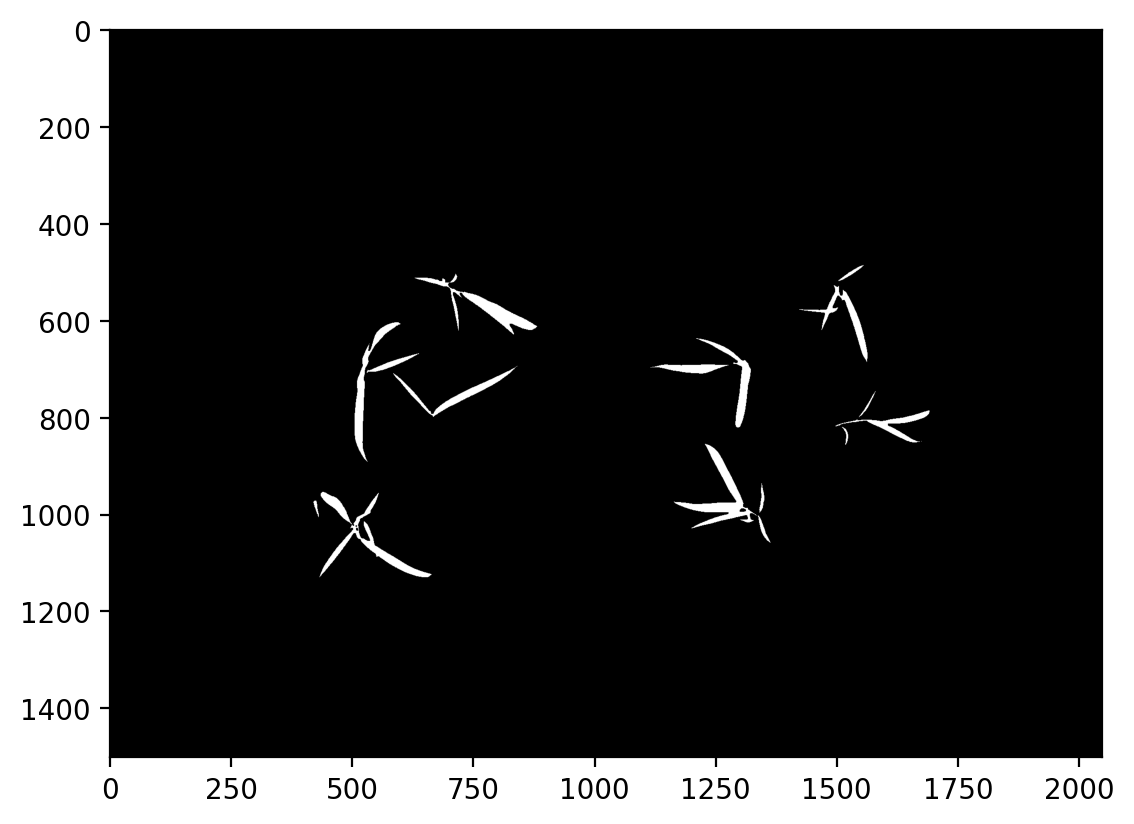

In [39]:
# Make a new filtered mask that only keeps the plant in your ROI and not objects outside of the ROI
# We have set to partial here so that if a leaf extends outside of your ROI it will still be selected. Switch to "cutto" if you have other plants that are getting selected on accident

# Inputs:
#    mask            = the clean mask you made above
#    roi            = the region of interest you specified above
#    roi_type       = 'partial' (default, for partially inside the ROI), 'cutto', or 
#                     'largest' (keep only largest contour)

mask = pcv.roi.filter(
    mask=eroded_mask, 
    roi=roi, 
    roi_type='partial'
    )

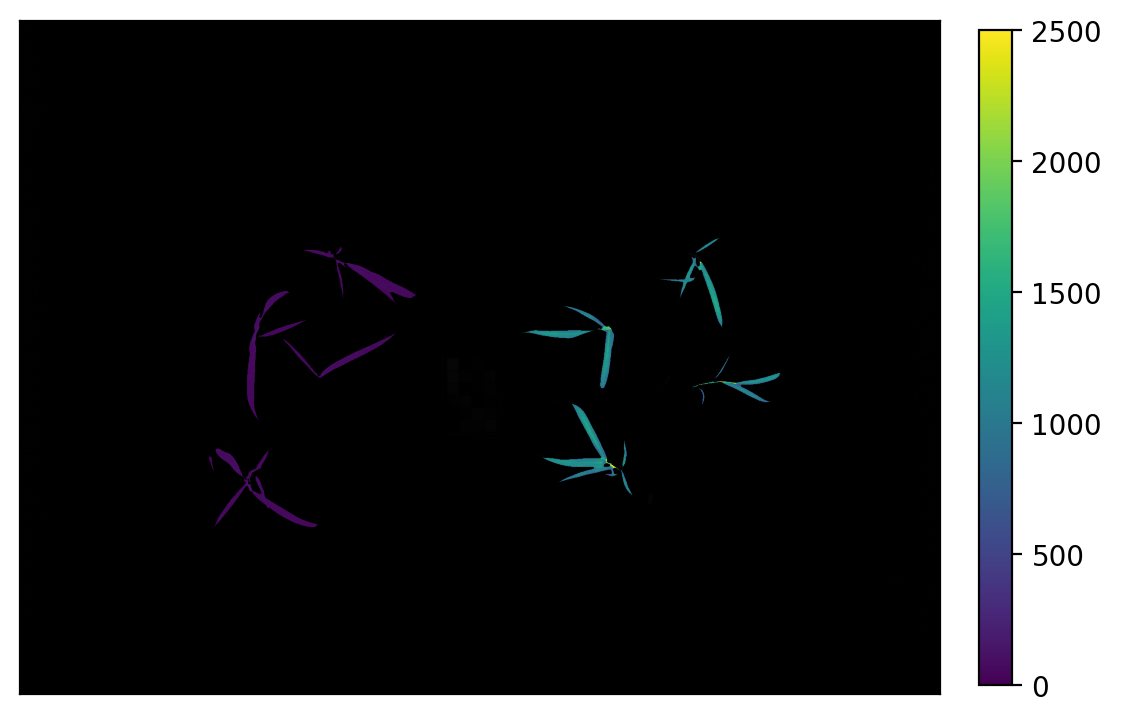

In [40]:
# Pseudocolor image with leaf mask
pseudo_img = pcv.visualize.pseudocolor(
    gray_img=gfp_img, 
    mask=mask, 
    cmap='viridis',
    min_value=0, 
    max_value=2500
    )

In [41]:
# Save stored data out to a file 
pcv.outputs.save_results(filename=args.result, outformat="json")